In [1]:
import sys, os

sys.path.insert(0, "../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import time
from pycbc.types import FrequencySeries
from modules.Classes_v2 import Precessing as P2, LensingGeo
from modules.Classes_v3 import Precessing as P3
from modules.Classes_v4 import Precessing as P4
from modules.default_params_v3 import *
from modules.functions_v3 import (
    set_to_location,
    calculate_cosJN,
    get_gw,
    mismatch_from_strains,
)

plt.rcParams["figure.dpi"] = 200

/Users/fairytien/Documents/TEXAS_Bridge_2324/code/lensing_and_precession/notebooks/../modules/Classes_v2.py:23: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):
/Users/fairytien/Documents/TEXAS_Bridge_2324/code/lensing_and_precession/notebooks/../modules/Classes_v2.py:23: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):


In [32]:
params_Ben = RP_params_1.copy()

# Use Ben's angles
params_Ben.update(
    {
        "theta_S": np.pi / 3,
        "phi_S": np.pi / 4,
        "theta_J": np.pi / 6,
        "phi_J": np.pi / 3,
        "theta_tilde": 8,
        "omega_tilde": 3.55,
        "gamma_P": 2.399,
    }
)
cos_JN = calculate_cosJN(
    params_Ben["phi_S"],
    params_Ben["theta_S"],
    params_Ben["phi_J"],
    params_Ben["theta_J"],
)
print(cos_JN)

order of arguments: phi_S, theta_S, phi_J, theta_J
0.8512708537611233


In [33]:
p2_Ben = P2(params_Ben)
p3_Ben = P3(params_Ben)

# Frequency array
f_min = 20
f_cut = p2_Ben.f_cut()
delta_f = 0.25
f_arr = np.arange(f_min, f_cut, delta_f)

Computation times (s):
       P2: 0.05874s
       P3: 0.00089s
  P4-RK45: 0.05740s
  P4-RK23: 0.19104s
  P4-DOP853: 0.07448s
  P4-LSODA: 0.06128s


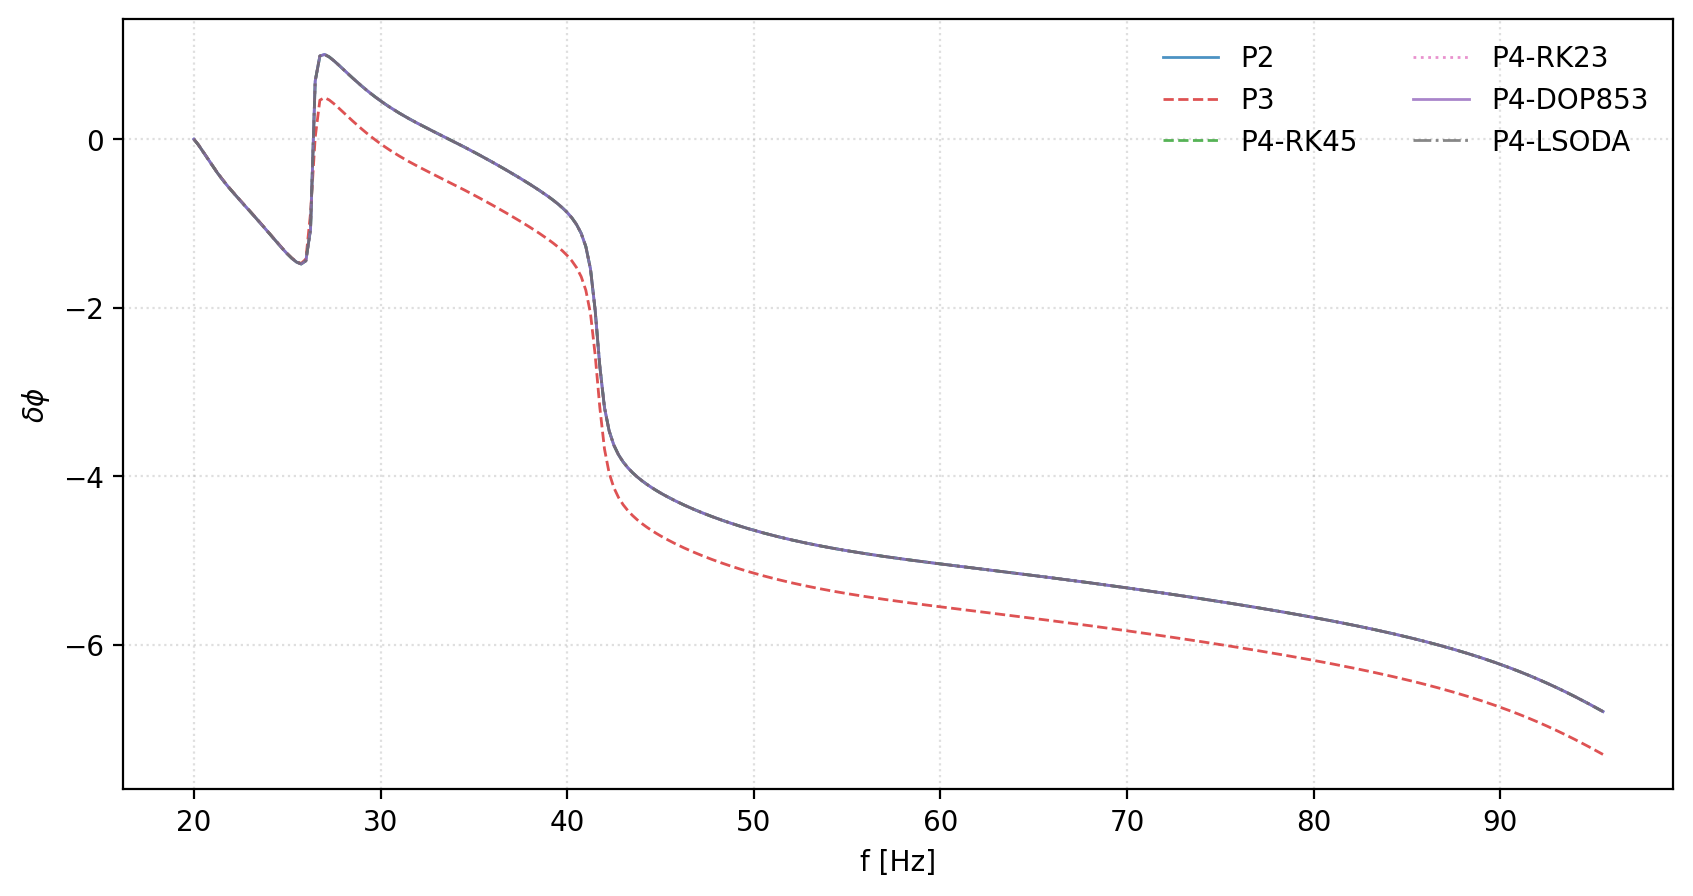

In [36]:
# Compare P2 (v2), P3 (v3), and P4 (various solve_ivp methods)
# Time each computation and plot with distinct styles

p2_Ben = P2(params_Ben)
p3_Ben = P3(params_Ben)
p4_Ben = P4(params_Ben)

methods = ["RK45", "RK23", "DOP853", "LSODA"]

results = {}
timings = {}

# P2
t0 = time.time()
phase2 = np.atleast_1d(p2_Ben.phase_delta_phi(f_arr))
timings["P2"] = time.time() - t0
results["P2"] = phase2

# P3
t0 = time.time()
phase3 = np.atleast_1d(p3_Ben.phase_delta_phi(f_arr))
timings["P3"] = time.time() - t0
results["P3"] = phase3

# P4 per-method timing
for m in methods:
    t0 = time.time()
    results[f"P4-{m}"] = np.atleast_1d(
        p4_Ben.phase_delta_phi(f_arr, ivp_method=m, rtol=1e-6, atol=1e-8)
    )
    timings[f"P4-{m}"] = time.time() - t0

# Print timings
print("Computation times (s):")
for k in ["P2", "P3"] + [f"P4-{m}" for m in methods]:
    print(f"  {k:>7}: {timings[k]:.5f}s")

# Style map
style_map = {
    "P2": ("tab:blue", "-"),
    "P3": ("tab:red", "--"),
    "P4-quad": ("tab:black", "-"),
    "P4-RK45": ("tab:green", "--"),
    "P4-RK23": ("tab:pink", ":"),
    "P4-DOP853": ("tab:purple", "-"),
    "P4-Radau": ("tab:orange", "--"),
    "P4-BDF": ("tab:brown", ":"),
    "P4-LSODA": ("dimgray", "-."),
}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_order = ["P2", "P3"] + [f"P4-{m}" for m in methods]
for key in plot_order:
    color, ls = style_map.get(key, (None, "-"))
    ax.plot(f_arr, results[key], label=key, lw=1, alpha=0.8, color=color, ls=ls)

ax.set_xlabel("f [Hz]")
ax.set_ylabel("$\delta\phi$")
ax.legend(ncol=2, frameon=False)
ax.grid(True, ls=":", alpha=0.4)
plt.show()

In [35]:
# Mismatch and fractional differences: compare all to P2 only

# Build strains (FrequencySeries) for P2, P3
h2 = p2_Ben.strain(f_arr, delta_f=delta_f, frequencySeries=True)
h3 = p3_Ben.strain(f_arr, delta_f=delta_f, frequencySeries=True)

# Build strains for P4 per method by plugging each phase_delta_phi into the formula
h4 = {}
for m in ["RK45", "RK23", "DOP853", "LSODA"]:
    try:
        h4[m] = p4_Ben.strain(
            f_arr, delta_f=delta_f, ivp_method=m, rtol=1e-8, atol=1e-10
        )
    except Exception as e:
        print(f"P4-{m} strain failed: {e}")

# Compute mismatches (only vs P2)
mm = {}
mm["P2_vs_P3"] = mismatch_from_strains(h2, h3, f_min=f_min, delta_f=delta_f)["mismatch"]
for m, h in h4.items():
    mm[f"P2_vs_P4-{m}"] = mismatch_from_strains(h2, h, f_min=f_min, delta_f=delta_f)[
        "mismatch"
    ]

print("Mismatches (vs P2):")
for k, v in mm.items():
    print(f"  {k:>14}: {v:.6e}")

Mismatches (vs P2):
        P2_vs_P3: 1.217345e-02
   P2_vs_P4-RK45: 5.795364e-14
   P2_vs_P4-RK23: 2.731149e-14
  P2_vs_P4-DOP853: 2.442491e-14
  P2_vs_P4-LSODA: 2.675637e-14
